# Customer Churn Prediction

## Objective
Build and evaluate machine learning models to identify bank customers
at risk of leaving and support customer retention decisions.

## Approach
- Load and validate the processed dataset
- Select predictors and the target variable
- Split data into training and test sets
- Prepare numerical and categorical features
- Compare a dummy baseline, Logistic Regression, and Random Forest
- Evaluate churn detection and explain model predictions

Target: churn (1 = left, 0 = stayed)

In [1]:
from pathlib import Path
import pandas as pd

data_path = Path(
    r"C:\Users\amish\OneDrive\Desktop\portfolio"
    r"\fintech-customer-churn-retention\data\processed"
    r"\bank_customer_churn_processed.csv"
)

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
print("Missing values:", df.isna().sum().sum())
print("Duplicate customer IDs:", df["customer_id"].duplicated().sum())

display(df.head())

print("\nChurn distribution (%):")
print(df["churn"].value_counts(normalize=True).mul(100).round(2))

Dataset shape: (10000, 18)
Missing values: 0
Duplicate customer IDs: 0


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,age_group,balance_group,credit_score_group,salary_group,activity_segment,product_segment
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1,36-45,0-50K,Fair,100K-150K,Active,1 Product
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,36-45,50K-100K,Fair,100K-150K,Active,1 Product
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,36-45,150K-200K,Poor,100K-150K,Inactive,3-4 Products
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0,36-45,0-50K,Good,50K-100K,Inactive,2 Products
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,36-45,100K-150K,Excellent,50K-100K,Active,1 Product



Churn distribution (%):
churn
0    79.63
1    20.37
Name: proportion, dtype: float64


In [2]:
# Select the customer attributes used to predict churn
feature_columns = [
    "credit_score",
    "country",
    "gender",
    "age",
    "tenure",
    "balance",
    "products_number",
    "credit_card",
    "active_member",
    "estimated_salary"
]

X = df[feature_columns].copy()
y = df["churn"].copy()

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())

Feature shape: (10000, 10)
Target shape: (10000,)


,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Test features:", X_test.shape)

print("\nTraining churn rate (%):", round(y_train.mean() * 100, 2))
print("Test churn rate (%):", round(y_test.mean() * 100, 2))

Training features: (8000, 10)
Test features: (2000, 10)

Training churn rate (%): 20.38
Test churn rate (%): 20.35


In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

numeric_features = [
    "credit_score",
    "age",
    "tenure",
    "balance",
    "products_number",
    "estimated_salary"
]

categorical_features = ["country", "gender"]

binary_features = ["credit_card", "active_member"]

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        ("binary", "passthrough", binary_features)
    ]
)

print("Preprocessor is ready.")

Preprocessor is ready.


In [5]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

# No preprocessing is needed for a model that ignores all features.
dummy_model = DummyClassifier(strategy="most_frequent")

baseline_scores = cross_validate(
    dummy_model,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc"
    }
)

baseline_results = pd.DataFrame({
    "Model": ["Dummy baseline"],
    "Accuracy": [baseline_scores["test_accuracy"].mean()],
    "Precision": [0.0],
    "Recall": [baseline_scores["test_recall"].mean()],
    "F1": [baseline_scores["test_f1"].mean()],
    "ROC-AUC": [baseline_scores["test_roc_auc"].mean()]
})

display(baseline_results.round(4))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Dummy baseline,0.7962,0.0,0.0,0.0,0.5


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone

logistic_model = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("classifier", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

logistic_scores = cross_validate(
    logistic_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

logistic_results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [logistic_scores["test_accuracy"].mean()],
    "Precision": [logistic_scores["test_precision"].mean()],
    "Recall": [logistic_scores["test_recall"].mean()],
    "F1": [logistic_scores["test_f1"].mean()],
    "ROC-AUC": [logistic_scores["test_roc_auc"].mean()]
})

comparison_results = pd.concat(
    [baseline_results, logistic_results],
    ignore_index=True
)

display(comparison_results.round(4))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Dummy baseline,0.7962,0.0000,0.0000,0.0000,0.5000
1,Logistic Regression,0.8104,0.5961,0.2135,0.3141,0.7628


In [7]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

random_forest_scores = cross_validate(
    random_forest_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

random_forest_results = pd.DataFrame({
    "Model": ["Random Forest"],
    "Accuracy": [random_forest_scores["test_accuracy"].mean()],
    "Precision": [random_forest_scores["test_precision"].mean()],
    "Recall": [random_forest_scores["test_recall"].mean()],
    "F1": [random_forest_scores["test_f1"].mean()],
    "ROC-AUC": [random_forest_scores["test_roc_auc"].mean()]
})

comparison_results = pd.concat(
    [baseline_results, logistic_results, random_forest_results],
    ignore_index=True
)

display(comparison_results.round(4))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Dummy baseline,0.7962,0.0000,0.0000,0.0000,0.5000
1,Logistic Regression,0.8104,0.5961,0.2135,0.3141,0.7628
2,Random Forest,0.8581,0.7513,0.4540,0.5659,0.8482


In [9]:
from sklearn.model_selection import RandomizedSearchCV

# Parallelize the search; each forest uses one worker.
rf_for_tuning = clone(random_forest_model).set_params(
    classifier__n_jobs=1
)

param_distributions = {
    "classifier__max_depth": [None, 8, 12, 16],
    "classifier__min_samples_split": [2, 10, 20],
    "classifier__min_samples_leaf": [1, 3, 5, 10],
    "classifier__max_features": ["sqrt", 0.7],
    "classifier__class_weight": [None, "balanced"]
}

rf_search = RandomizedSearchCV(
    estimator=rf_for_tuning,
    param_distributions=param_distributions,
    n_iter=20,
    scoring=scoring,
    refit="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)

print("Best parameters:")
print(rf_search.best_params_)

print("\nBest mean CV ROC-AUC:")
print(round(rf_search.best_score_, 4))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters:
{'classifier__min_samples_split': 20, 'classifier__min_samples_leaf': 10, 'classifier__max_features': 0.7, 'classifier__max_depth': 8, 'classifier__class_weight': 'balanced'}

Best mean CV ROC-AUC:
0.8614


In [10]:
# Retrieve scores for the parameter combination selected by ROC-AUC
best_index = rf_search.best_index_

tuned_rf_results = pd.DataFrame({
    "Model": ["Tuned Random Forest"],
    "Accuracy": [rf_search.cv_results_["mean_test_accuracy"][best_index]],
    "Precision": [rf_search.cv_results_["mean_test_precision"][best_index]],
    "Recall": [rf_search.cv_results_["mean_test_recall"][best_index]],
    "F1": [rf_search.cv_results_["mean_test_f1"][best_index]],
    "ROC-AUC": [rf_search.cv_results_["mean_test_roc_auc"][best_index]]
})

comparison_results = pd.concat(
    [
        baseline_results,
        logistic_results,
        random_forest_results,
        tuned_rf_results
    ],
    ignore_index=True
)

# This pipeline is already fitted on all training data
best_rf_model = rf_search.best_estimator_

display(comparison_results.round(4))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Dummy baseline,0.7962,0.0000,0.0000,0.0000,0.5000
1,Logistic Regression,0.8104,0.5961,0.2135,0.3141,0.7628
2,Random Forest,0.8581,0.7513,0.4540,0.5659,0.8482
3,Tuned Random Forest,0.8092,0.5231,0.7141,0.6036,0.8614


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Tuned Random Forest — Test,0.81,0.5235,0.7396,0.613,0.8622


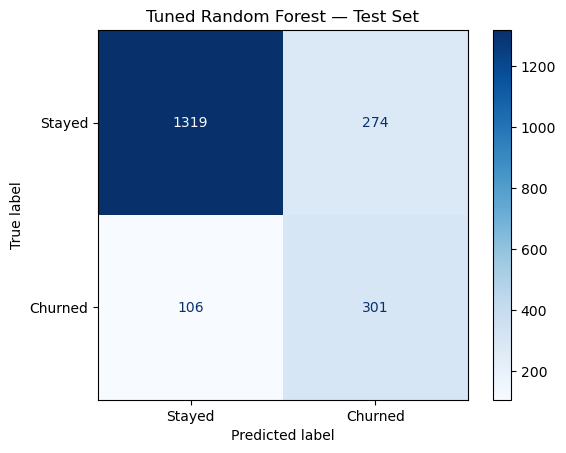

In [11]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Evaluate the already-fitted pipeline on the reserved test set
y_test_probability = best_rf_model.predict_proba(X_test)[:, 1]
y_test_prediction = (y_test_probability >= 0.50).astype(int)

test_results = pd.DataFrame({
    "Model": ["Tuned Random Forest — Test"],
    "Accuracy": [accuracy_score(y_test, y_test_prediction)],
    "Precision": [
        precision_score(y_test, y_test_prediction, zero_division=0)
    ],
    "Recall": [recall_score(y_test, y_test_prediction)],
    "F1": [f1_score(y_test, y_test_prediction)],
    "ROC-AUC": [roc_auc_score(y_test, y_test_probability)]
})

display(test_results.round(4))

cm = confusion_matrix(y_test, y_test_prediction, labels=[0, 1])

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stayed", "Churned"]
).plot(cmap="Blues", values_format="d")

plt.title("Tuned Random Forest — Test Set")
plt.show()

,Feature,Mean ROC-AUC decrease,Standard deviation
6,products_number,0.1253,0.0112
3,age,0.1169,0.0046
5,balance,0.0409,0.0062
8,active_member,0.0298,0.0036
1,country,0.0247,0.0023
2,gender,0.0036,0.0016
7,credit_card,0.0002,0.0003
9,estimated_salary,-0.0011,0.0010
4,tenure,-0.0016,0.0007
0,credit_score,-0.0017,0.0008


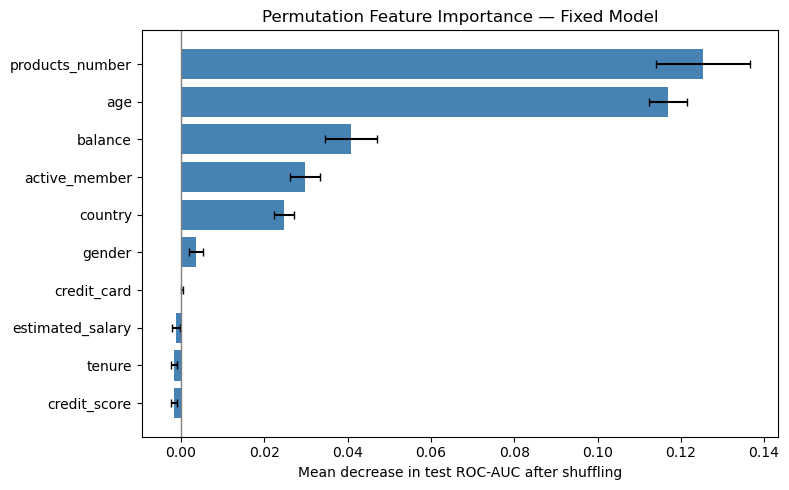

In [12]:
from sklearn.inspection import permutation_importance

# Interpret the fixed model; do not use these results to retune it
permutation_results = permutation_importance(
    best_rf_model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42,
    n_jobs=2
)

feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean ROC-AUC decrease": permutation_results.importances_mean,
    "Standard deviation": permutation_results.importances_std
}).sort_values("Mean ROC-AUC decrease", ascending=False)

display(feature_importance.round(4))

plot_data = feature_importance.sort_values("Mean ROC-AUC decrease")

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    plot_data["Feature"],
    plot_data["Mean ROC-AUC decrease"],
    xerr=plot_data["Standard deviation"],
    color="steelblue",
    capsize=3
)

ax.axvline(0, color="gray", linewidth=1)
ax.set_xlabel("Mean decrease in test ROC-AUC after shuffling")
ax.set_title("Permutation Feature Importance — Fixed Model")
plt.tight_layout()
plt.show()

In [13]:
from pathlib import Path
import joblib
import sklearn

# Use the project location from your data-loading cell
project_path = data_path.parent.parent.parent

models_path = project_path / "models"
reports_path = project_path / "reports"
processed_path = project_path / "data" / "processed"

for folder in [models_path, reports_path, processed_path]:
    folder.mkdir(parents=True, exist_ok=True)

# Save preprocessing, fitted model, and prediction settings together
model_bundle = {
    "pipeline": best_rf_model,
    "feature_columns": feature_columns,
    "threshold": 0.50,
    "positive_class": 1,
    "sklearn_version": sklearn.__version__
}

model_file = models_path / "churn_random_forest_bundle.joblib"
joblib.dump(model_bundle, model_file)

# Export cross-validation and final test results separately
comparison_results.to_csv(
    reports_path / "model_comparison_cv.csv", index=False
)

test_results.to_csv(
    reports_path / "final_model_test_metrics.csv", index=False
)

feature_importance.to_csv(
    reports_path / "permutation_feature_importance.csv", index=False
)

# Preserve test-row order when attaching predictions to customer records
test_predictions = df.loc[X_test.index].copy()
test_predictions = test_predictions.rename(columns={"churn": "actual_churn"})

test_predictions["churn_score"] = y_test_probability
test_predictions["predicted_churn"] = y_test_prediction
test_predictions["decision_threshold"] = 0.50
test_predictions["dataset_split"] = "test"

predictions_file = processed_path / "churn_test_predictions.csv"
test_predictions.to_csv(predictions_file, index=False)

# Check that the saved model reproduces the original scores
loaded_bundle = joblib.load(model_file)
reloaded_scores = loaded_bundle["pipeline"].predict_proba(X_test)[:, 1]

import numpy as np
np.testing.assert_allclose(reloaded_scores, y_test_probability)

print("Model saved and reload check passed.")
print("Test customers exported:", len(test_predictions))
print("Model file:", model_file)
print("Predictions file:", predictions_file)
print("Reports folder:", reports_path)

display(test_predictions.head())

Model saved and reload check passed.
Test customers exported: 2000
Model file: C:\Users\amish\OneDrive\Desktop\portfolio\fintech-customer-churn-retention\models\churn_random_forest_bundle.joblib
Predictions file: C:\Users\amish\OneDrive\Desktop\portfolio\fintech-customer-churn-retention\data\processed\churn_test_predictions.csv
Reports folder: C:\Users\amish\OneDrive\Desktop\portfolio\fintech-customer-churn-retention\reports


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,...,age_group,balance_group,credit_score_group,salary_group,activity_segment,product_segment,churn_score,predicted_churn,decision_threshold,dataset_split
5702,15749540,585,France,Male,36,7,0.00,2,1,0,...,36-45,0-50K,Fair,50K-100K,Inactive,2 Products,0.036672,0,0.5,test
3667,15807340,525,Germany,Male,33,4,131023.76,2,0,0,...,26-35,100K-150K,Poor,50K-100K,Inactive,2 Products,0.127558,0,0.5,test
1617,15801062,557,Spain,Female,40,4,0.00,2,0,1,...,36-45,0-50K,Poor,100K-150K,Active,2 Products,0.107277,0,0.5,test
5673,15572801,639,Spain,Male,34,5,139393.19,2,0,0,...,26-35,100K-150K,Fair,0-50K,Inactive,2 Products,0.147497,0,0.5,test
4272,15600708,640,Spain,Female,34,3,77826.80,1,1,1,...,26-35,50K-100K,Fair,150K+,Active,1 Product,0.245211,0,0.5,test
